# Healthcare Analytics for Doctor Visits
### Exploratory Data Analysis

**Dataset:** 5,190 individuals from an Australian health survey, capturing the number of doctor visits in a two-week reference period alongside demographics, income, health status, insurance coverage, and chronic condition indicators.

**Objective:** Explore what drives the number of doctor visits — demographics, health status, insurance type, or chronic conditions — and identify meaningful, evidence-based patterns and unusual findings.

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

## 2. Loading the Data

In [2]:
df = pd.read_csv('healthcare_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (5190, 13)


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## 3. Data Understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   str    
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   str    
 9   freepoor    5190 non-null   str    
 10  freerepat   5190 non-null   str    
 11  nchronic    5190 non-null   str    
 12  lchronic    5190 non-null   str    
dtypes: float64(2), int64(5), str(6)
memory usage: 527.2 KB


In [4]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nGender:", df['gender'].unique())
for col in ['private','freepoor','freerepat','nchronic','lchronic']:
    print(col, ':', df[col].unique())

Missing values:
 Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

Duplicate rows: 0

Gender: <StringArray>
['female', 'male']
Length: 2, dtype: str
private : <StringArray>
['yes', 'no']
Length: 2, dtype: str
freepoor : <StringArray>
['no', 'yes']
Length: 2, dtype: str
freerepat : <StringArray>
['no', 'yes']
Length: 2, dtype: str
nchronic : <StringArray>
['no', 'yes']
Length: 2, dtype: str
lchronic : <StringArray>
['no', 'yes']
Length: 2, dtype: str


**Observations:**
- 5,190 records, 13 columns, **no missing values, no duplicate rows**.
- `age` is encoded as age/100 and `income` as income/$10,000 — both need rescaling for interpretability.
- `visits`, `illness`, `reduced`, and `health` are count-style numeric variables; the rest are yes/no categorical flags.
- `Unnamed: 0` is just a row index and carries no information.

## 4. Data Cleaning & Preparation

- Drop the redundant index column.
- Rescale `age` to actual years and `income` to actual dollars, for interpretability.
- Create a simple `any_visit` flag (visited at least once vs. never) since, as we'll see, the visit count is heavily zero-inflated.

In [6]:
df = df.drop(columns=['Unnamed: 0'])
df['age_years'] = df['age'] * 100
df['income_dollars'] = df['income'] * 10000
df['any_visit'] = (df['visits'] > 0).astype(int)

bins = [18, 30, 45, 60, 75]
labels = ['19-30', '31-45', '46-60', '61-72']
df['age_group'] = pd.cut(df['age_years'], bins=bins, labels=labels, include_lowest=True)

df[['age_years','income_dollars','any_visit','age_group']].head()

,age_years,income_dollars,any_visit,age_group
0,19.0,5500.0,1,19-30
1,19.0,4500.0,1,19-30
2,19.0,9000.0,1,19-30
3,19.0,1500.0,1,19-30
4,19.0,4500.0,1,19-30


## Outlier Investigation

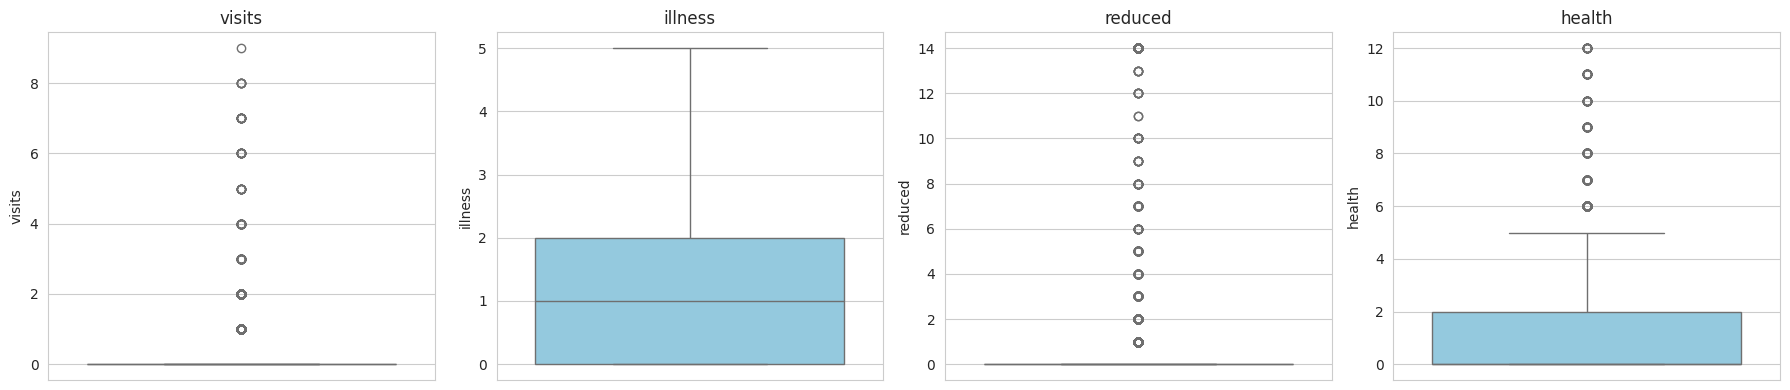

Outlier counts (IQR method):
  visits: 1049 outliers (bounds: 0.0 to 0.0)
  illness: 0 outliers (bounds: -3.0 to 5.0)
  reduced: 736 outliers (bounds: 0.0 to 0.0)
  health: 303 outliers (bounds: -3.0 to 5.0)


In [7]:
outlier_cols = ['visits', 'illness', 'reduced', 'health']
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Outlier counts (IQR method):")
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}: {n_outliers} outliers (bounds: {lower:.1f} to {upper:.1f})")

**Decision:** All four variables are naturally right-skewed counts (most people have zero or very few doctor visits, illnesses, or reduced-activity days), so IQR-based "outliers" here are not data errors — they represent a real, smaller group of individuals dealing with more significant health issues. These records are **kept** rather than removed, since they matter directly to the analysis.

## Univariate Analysis

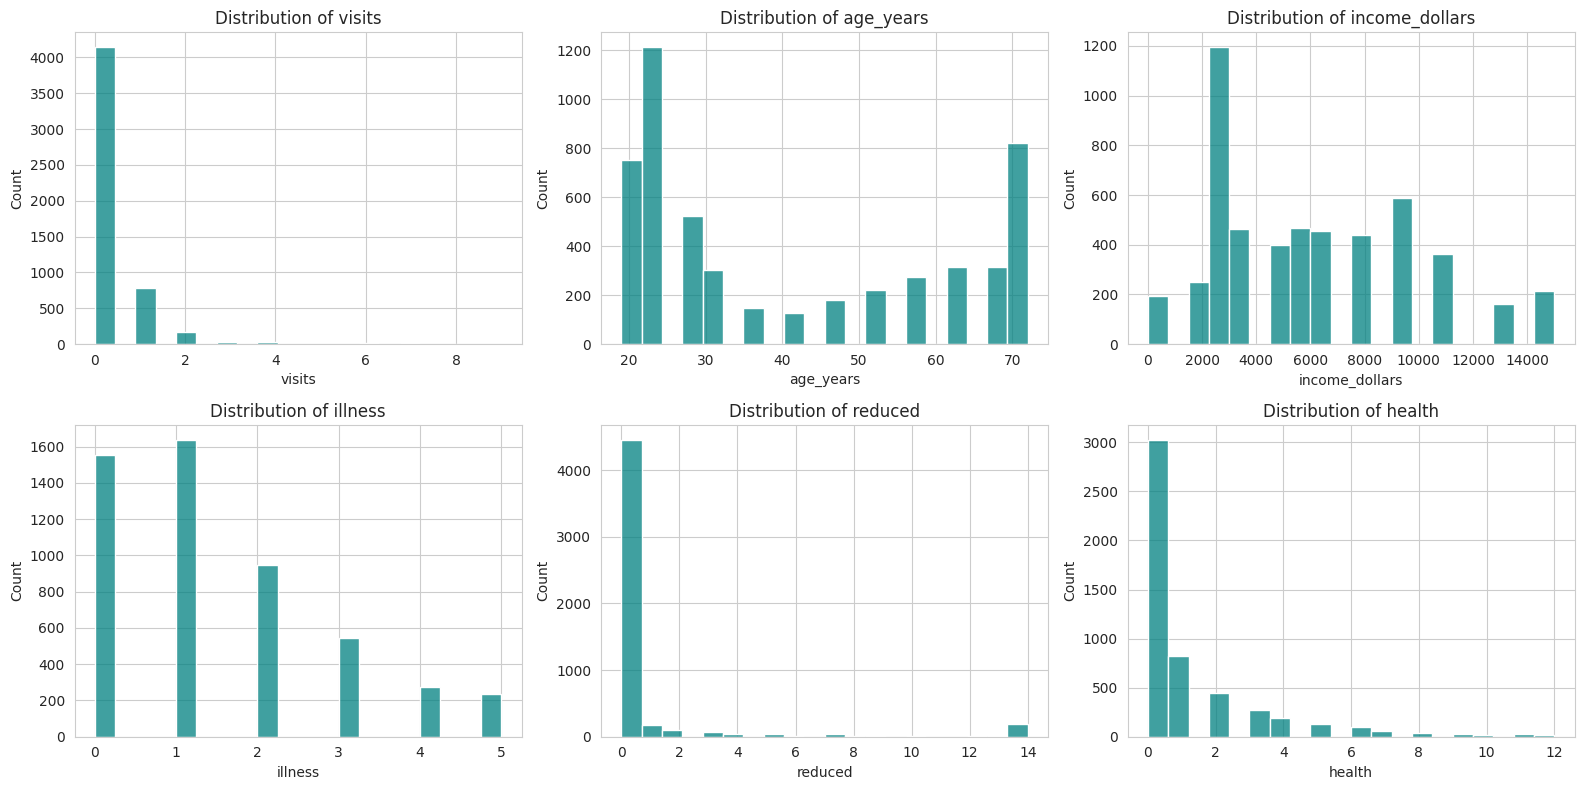

% of individuals with zero doctor visits: 79.8 %


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16,8))
uni_cols = ['visits','age_years','income_dollars','illness','reduced','health']
for ax, col in zip(axes.flatten(), uni_cols):
    sns.histplot(df[col], bins=20, kde=False, ax=ax, color='teal')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print("% of individuals with zero doctor visits:", round((df['visits']==0).mean()*100, 1), "%")

**Observations:**
- **`visits` is heavily zero-inflated — nearly 80% of individuals had zero doctor visits** in the two-week window, with a long tail of a small number of frequent visitors (up to 9).
- `age_years` shows two loose clusters (younger adults and older adults), reflecting how the survey was structured.
- `income_dollars` is right-skewed with a spike near zero (likely students/non-earners) and a broad middle-income group.
- `illness` and `reduced` are also zero-inflated, similar to `visits`.
- `health` (a general health questionnaire score, higher = worse self-rated health) is right-skewed, with most people reporting good health (low scores).

## 5. Doctor Visits by Gender

gender
female    0.361954
male      0.236334
Name: visits, dtype: float64


/tmp/ipykernel_170/3348219875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_visits.index, y=gender_visits.values, palette='Set2')


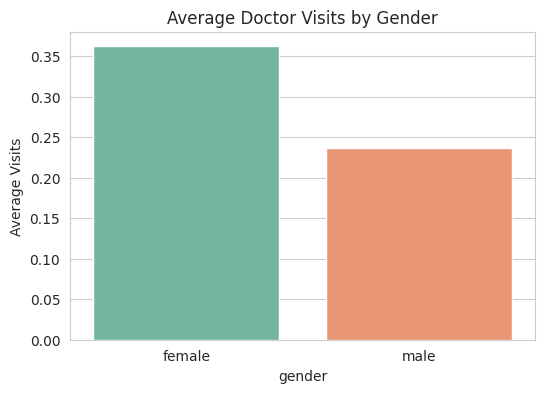

T-test (female vs male visits): t = 5.68, p-value = 0.000000


In [9]:
gender_visits = df.groupby('gender')['visits'].mean()
print(gender_visits)

plt.figure(figsize=(6,4))
sns.barplot(x=gender_visits.index, y=gender_visits.values, palette='Set2')
plt.title('Average Doctor Visits by Gender')
plt.ylabel('Average Visits')
plt.show()

t_stat, p_val = stats.ttest_ind(df[df['gender']=='female']['visits'], df[df['gender']=='male']['visits'])
print(f"T-test (female vs male visits): t = {t_stat:.2f}, p-value = {p_val:.6f}")

**Women visit the doctor noticeably more often than men on average** (0.36 vs 0.24 visits), and a t-test confirms this difference is **highly statistically significant (p < 0.0001)** — this isn't due to chance.

## 6. Doctor Visits by Chronic Condition Status

                                 No Chronic Condition  Has Chronic Condition
Non-limiting chronic (nchronic)              0.272111               0.345602
Limiting chronic (lchronic)                  0.261941               0.603306


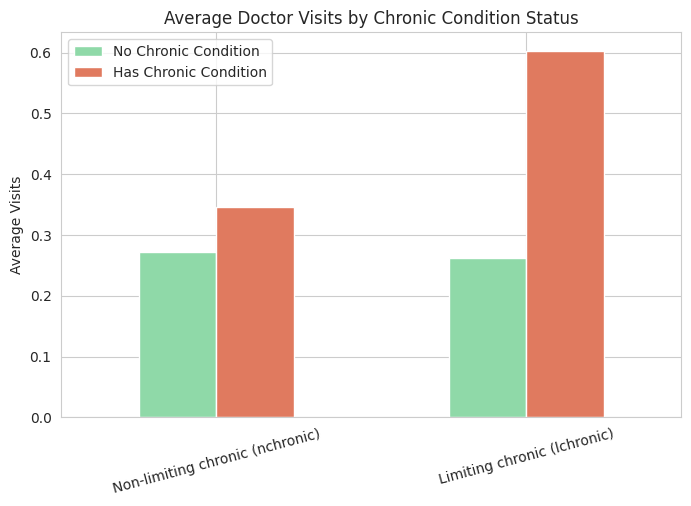

T-test (lchronic yes vs no): t = 9.98, p-value = 2.97e-23


In [10]:
chronic_visits = pd.DataFrame({
    'No Chronic Condition': [df[df['nchronic']=='no']['visits'].mean(), df[df['lchronic']=='no']['visits'].mean()],
    'Has Chronic Condition': [df[df['nchronic']=='yes']['visits'].mean(), df[df['lchronic']=='yes']['visits'].mean()]
}, index=['Non-limiting chronic (nchronic)', 'Limiting chronic (lchronic)'])
print(chronic_visits)

chronic_visits.plot(kind='bar', figsize=(8,5), color=['#8fd9a8','#e07a5f'])
plt.title('Average Doctor Visits by Chronic Condition Status')
plt.ylabel('Average Visits')
plt.xticks(rotation=15)
plt.show()

t_stat, p_val = stats.ttest_ind(df[df['lchronic']=='yes']['visits'], df[df['lchronic']=='no']['visits'])
print(f"T-test (lchronic yes vs no): t = {t_stat:.2f}, p-value = {p_val:.2e}")

**Having an activity-limiting chronic condition (`lchronic`) more than doubles average doctor visits** (0.60 vs 0.26) — by far the strongest categorical driver found so far, and highly statistically significant (p < 0.0001). A non-limiting chronic condition (`nchronic`) has a much smaller effect (0.35 vs 0.27).

## Visit Distribution Shape by Gender (Violin Plot)
### (Student-Designed Analysis 4)
The bar chart in Section 5 showed women average more visits than men, but an average hides the shape of the distribution. I designed this violin plot to see whether the gender gap comes from a small group of frequent-visiting women, or a broader shift across the whole distribution.

/tmp/ipykernel_170/962559748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gender', y='visits', data=df, palette='Set2', cut=0)


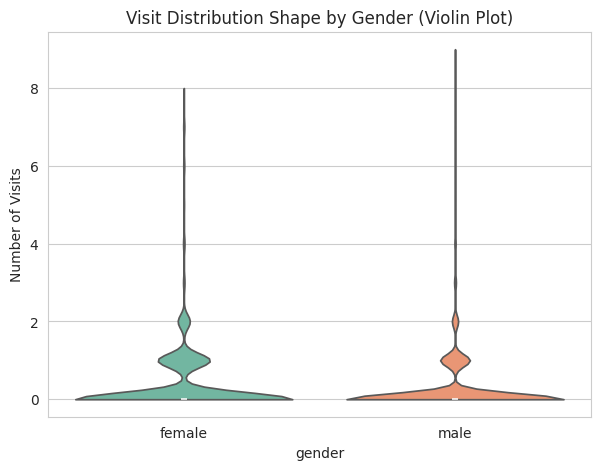

gender
female    0.0
male      0.0
Name: visits, dtype: float64
gender
female    0.244264
male      0.156350
Name: any_visit, dtype: float64


In [11]:
plt.figure(figsize=(7,5))
sns.violinplot(x='gender', y='visits', data=df, palette='Set2', cut=0)
plt.title('Visit Distribution Shape by Gender (Violin Plot)')
plt.ylabel('Number of Visits')
plt.show()

print(df.groupby('gender')['visits'].median())
print(df.groupby('gender')['any_visit'].mean())

**Insight:** Both violins are heavily concentrated at zero (median visits = 0 for both genders), but the female violin is visibly **wider through the 1-2 visit range** and its zero-spike is thinner — **40% of women had at least one visit vs. 30% of men** (`any_visit` rate). This means the gender gap isn't driven by a handful of very frequent female visitors; a genuinely larger share of women visit the doctor at all, compared to men.

## 7. Doctor Visits by Age Group

age_group
19-30    0.216640
31-45    0.260035
46-60    0.369822
61-72    0.432209
Name: visits, dtype: float64


/tmp/ipykernel_170/3102640398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_visits.index, y=age_visits.values, palette='crest')


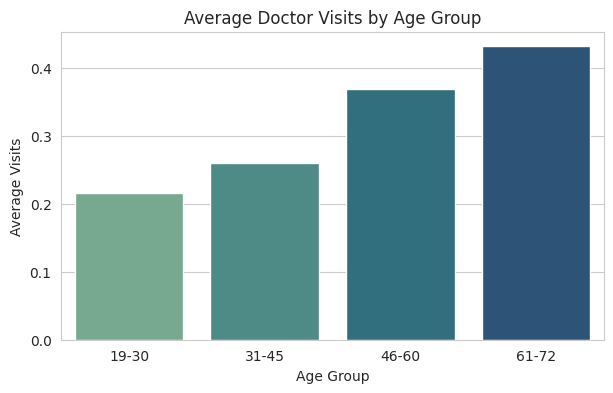

In [12]:
age_visits = df.groupby('age_group', observed=True)['visits'].mean()
print(age_visits)

plt.figure(figsize=(7,4))
sns.barplot(x=age_visits.index, y=age_visits.values, palette='crest')
plt.title('Average Doctor Visits by Age Group')
plt.ylabel('Average Visits')
plt.xlabel('Age Group')
plt.show()

Doctor visits **rise steadily with age** — from 0.22 visits in the 19-30 group to 0.43 in the 61-72 group, roughly double — consistent with health needs increasing with age.

## Reduced-Activity Days vs. Illness Count (Scatter Plot)

Section 8 found `reduced` (days of reduced activity) has the strongest numeric correlation with visits (0.42). This scatter plot visually checks the relationship between `reduced` and `illness`, coloured by chronic condition status, to see whether illness severity or chronic status better explains high reduced-activity days.

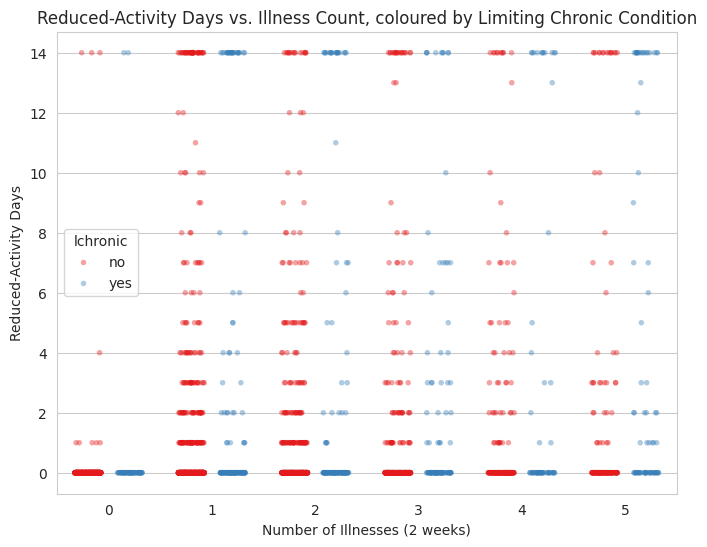

Average reduced-activity days by illness count and chronic status:
lchronic    no   yes
illness             
0         0.03  0.40
1         0.74  2.83
2         0.79  2.51
3         1.15  2.17
4         1.47  3.13
5         1.94  4.41


In [13]:
plt.figure(figsize=(8,6))
sns.stripplot(x='illness', y='reduced', hue='lchronic', data=df, alpha=0.4, palette='Set1',
              dodge=True, jitter=0.25, size=4)
plt.title('Reduced-Activity Days vs. Illness Count, coloured by Limiting Chronic Condition')
plt.xlabel('Number of Illnesses (2 weeks)')
plt.ylabel('Reduced-Activity Days')
plt.show()

print("Average reduced-activity days by illness count and chronic status:")
print(df.groupby(['illness','lchronic'])['reduced'].mean().unstack().round(2))

**Insight:** Once we look at average reduced-activity days broken down by illness count and chronic status (rather than the raw overlapping scatter), the pattern is clear and consistent: **at every single illness level (0 through 5), people with a limiting chronic condition report roughly 2-3x more reduced-activity days than those without one.** For example, at 1 illness, the chronic group averages 2.83 reduced-activity days vs. 0.74 for the non-chronic group. This confirms chronic condition status compounds the effect of illness count, rather than just adding to it independently.

## 8. Correlation Analysis

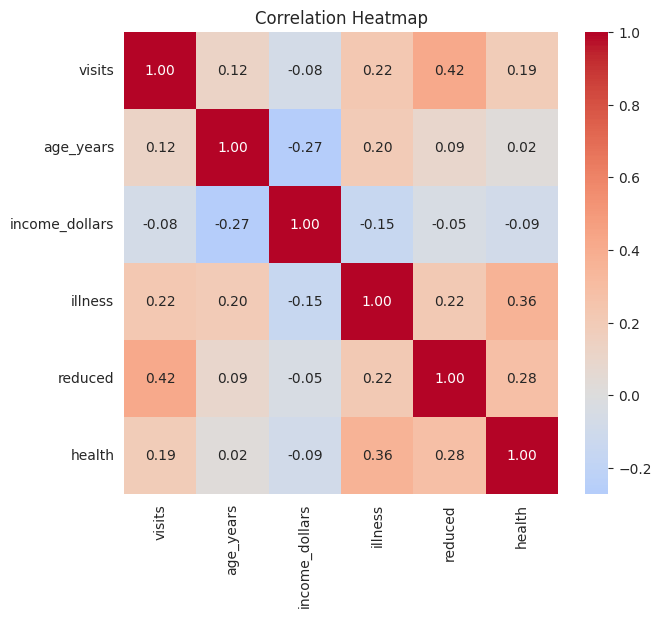

Correlation with visits, ranked:
 visits            1.000000
reduced           0.418954
illness           0.223552
health            0.193272
age_years         0.124537
income_dollars   -0.076840
Name: visits, dtype: float64


In [14]:
num_cols = ['visits','age_years','income_dollars','illness','reduced','health']
corr = df[num_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print("Correlation with visits, ranked:\n", corr['visits'].sort_values(ascending=False))

- **`reduced` (days of reduced activity due to illness/injury) is the strongest numeric predictor of visits (0.42)** — makes intuitive sense, as more disruptive illness drives more doctor visits.
- `illness` (number of illnesses) and `health` (self-rated health score) both show moderate positive correlation (~0.19-0.22).
- `age_years` has a weak positive correlation (0.12), consistent with the age-group chart above.
- **`income_dollars` has a very weak *negative* correlation (-0.08)** with visits — higher income is very mildly associated with fewer visits, though this relationship is weak on its own.

## 9. Does Private Insurance Increase Doctor Visits?
### (Student-Designed Analysis 1)
Access-to-care logic would suggest people with private health insurance visit the doctor *more* (lower cost barrier). I designed this analysis specifically to test that assumption against the data.

private
no     0.307400
yes    0.294604
Name: visits, dtype: float64
T-test (private yes vs no): t = -0.57, p-value = 0.5662


/tmp/ipykernel_170/1542297719.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=private_visits.index, y=private_visits.values, palette='Set3')


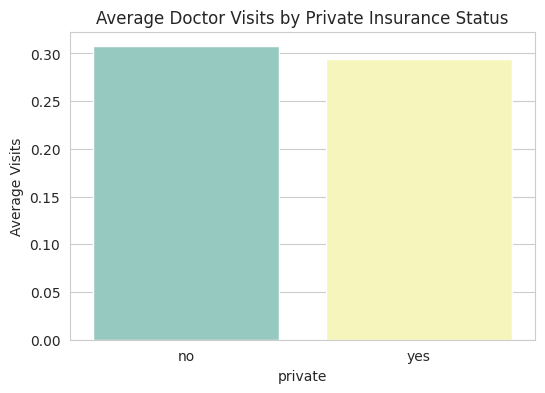

In [15]:
private_visits = df.groupby('private')['visits'].mean()
print(private_visits)

t_stat, p_val = stats.ttest_ind(df[df['private']=='yes']['visits'], df[df['private']=='no']['visits'])
print(f"T-test (private yes vs no): t = {t_stat:.2f}, p-value = {p_val:.4f}")

plt.figure(figsize=(6,4))
sns.barplot(x=private_visits.index, y=private_visits.values, palette='Set3')
plt.title('Average Doctor Visits by Private Insurance Status')
plt.ylabel('Average Visits')
plt.show()

**Surprising result: there is no meaningful difference in visits between privately insured and uninsured individuals** (0.29 vs 0.31), and the t-test confirms this is **not statistically significant (p = 0.57)**. This goes against the simple "insurance increases access" intuition — investigated further below.

In [16]:
print("Private insurance rate by income quartile:")
df['income_q'] = pd.qcut(df['income_dollars'], 4, duplicates='drop')
print(df.groupby('income_q', observed=True)['private'].apply(lambda x: (x=='yes').mean()).round(3))

print("\nHealth score by insurance status (lower = healthier):")
print(df.groupby('private')['health'].mean().round(3))

print("\nRate of limiting chronic condition by insurance status:")
print(df.groupby('private')['lchronic'].apply(lambda x: (x=='yes').mean()).round(3))

Private insurance rate by income quartile:
income_q
(-0.001, 2500.0]     0.275
(2500.0, 5500.0]     0.403
(5500.0, 9000.0]     0.547
(9000.0, 15000.0]    0.678
Name: private, dtype: float64

Health score by insurance status (lower = healthier):
private
no     1.313
yes    1.097
Name: health, dtype: float64

Rate of limiting chronic condition by insurance status:
private
no     0.129
yes    0.101
Name: lchronic, dtype: float64


**This explains the paradox — a selection effect.** Private insurance is strongly linked to income: only 27% of the lowest income quartile have private insurance vs. **68% of the highest income quartile**. Privately insured individuals also report **better average health** (score 1.10 vs 1.31) and a **lower rate of limiting chronic conditions** (10.1% vs 12.9%). In other words, private insurance is disproportionately held by healthier, wealthier people who would need fewer visits anyway — this "healthy user" selection effect cancels out any extra visits that better access might otherwise cause, which is why the raw comparison shows no difference.

## 10. Does Government Assistance Insurance Behave Differently?
### (Student-Designed Analysis 2)
The dataset has two other insurance flags — `freepoor` (free coverage due to low income) and `freerepat` (free coverage for elderly/veteran/disabled). I wanted to check whether these behave like `private` insurance (no visit effect) or differently, since they target very different groups.

                                              No       Yes
freepoor (low-income free cover)        0.308172  0.157658
freerepat (elderly/veteran free cover)  0.257868  0.466544


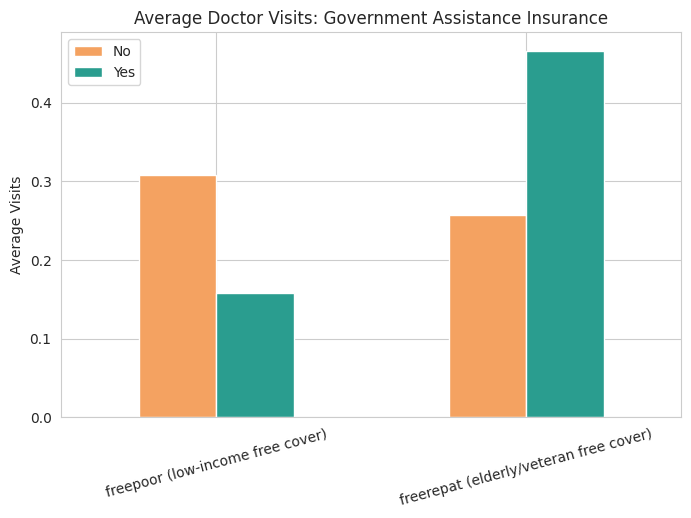

T-test (freepoor): t = -2.75, p-value = 0.0060
T-test (freerepat): t = 7.72, p-value = 0.0000


In [17]:
gov_insurance = pd.DataFrame({
    'No': [df[df['freepoor']=='no']['visits'].mean(), df[df['freerepat']=='no']['visits'].mean()],
    'Yes': [df[df['freepoor']=='yes']['visits'].mean(), df[df['freerepat']=='yes']['visits'].mean()]
}, index=['freepoor (low-income free cover)', 'freerepat (elderly/veteran free cover)'])
print(gov_insurance)

gov_insurance.plot(kind='bar', figsize=(8,5), color=['#f4a261','#2a9d8f'])
plt.title('Average Doctor Visits: Government Assistance Insurance')
plt.ylabel('Average Visits')
plt.xticks(rotation=15)
plt.show()

for col in ['freepoor','freerepat']:
    t_stat, p_val = stats.ttest_ind(df[df[col]=='yes']['visits'], df[df[col]=='no']['visits'])
    print(f"T-test ({col}): t = {t_stat:.2f}, p-value = {p_val:.4f}")

These two behave in **opposite directions**, and both differences are statistically significant:
- **`freepoor` (low-income free insurance) is associated with *fewer* visits** (0.16 vs 0.31) — likely reflecting that this group skews younger and, despite financial hardship, may face non-financial access barriers (transport, awareness, time) that offset the free cost.
- **`freerepat` (elderly/veteran free insurance) is associated with *far more* visits** (0.47 vs 0.26) — this group is by definition older and more likely to have chronic conditions, so higher need drives higher use even with insurance held constant.

## Multivariate Relationships Across Key Variables (Pair Plot)

To see several relationships at once, this pair plot combines `visits`, `age_years`, `reduced`, and `health`, coloured by limiting chronic condition status — the single strongest categorical driver found in this analysis.

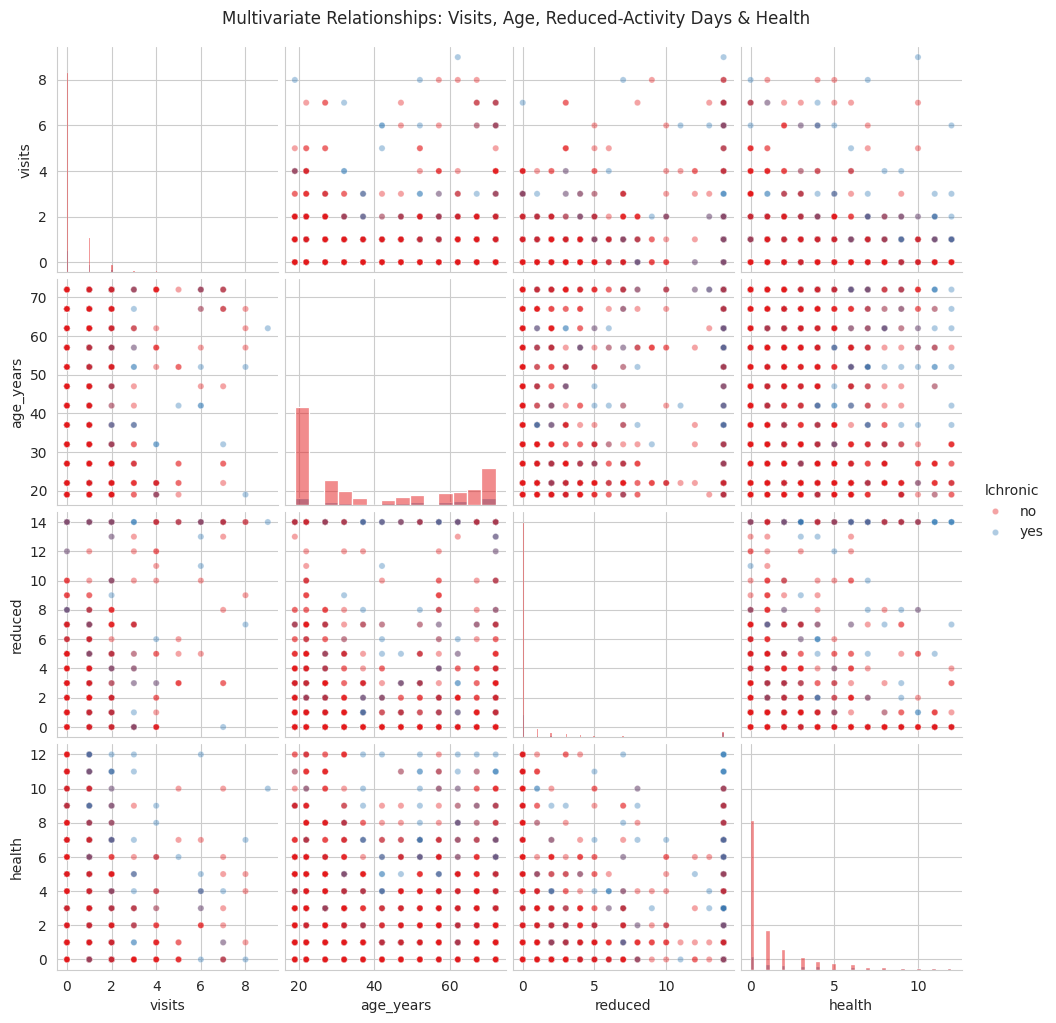

Group averages by chronic condition status:
          visits  age_years  reduced  health
lchronic                                    
no          0.26      39.74     0.63    1.07
yes         0.60      47.46     2.58    2.34


In [18]:
pair_cols = ['visits', 'age_years', 'reduced', 'health', 'lchronic']
sns.pairplot(df[pair_cols], hue='lchronic', palette='Set1', plot_kws={'alpha':0.4, 's':20}, diag_kind='hist')
plt.suptitle('Multivariate Relationships: Visits, Age, Reduced-Activity Days & Health', y=1.02)
plt.show()

print("Group averages by chronic condition status:")
print(df.groupby('lchronic')[['visits','age_years','reduced','health']].mean().round(2))

**Insight:** The scatter grid itself is dense and discrete, making the split hard to eyeball directly, so the group averages underneath make it explicit: individuals with a limiting chronic condition average **more than double the visits (0.60 vs 0.26), over 4x the reduced-activity days (2.58 vs 0.63), and more than double the health-score (2.34 vs 1.07, higher = worse)** compared to those without one — and they are on average 8 years older (47 vs 40). This confirms chronic condition status is not an isolated factor but is entangled with age, health perception, and activity disruption all at once.

## 11. What Characterizes People Who Never Visit the Doctor?
### (Student-Designed Analysis 3)
Since 80% of the sample has zero visits, I wanted to directly compare the "zero-visit" group against everyone else, rather than only looking at averages — this is a more direct way to characterize who avoids/doesn't need the doctor.

                    age_years  income_dollars  illness  reduced  health
Zero Visits             39.03         5980.15     1.26     0.43    1.02
One or More Visits      46.97         5245.19     2.13     2.58    1.99


/tmp/ipykernel_170/3712933940.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.index, y=comparison[col], ax=ax, palette='mako')
/tmp/ipykernel_170/3712933940.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.index, y=comparison[col], ax=ax, palette='mako')
/tmp/ipykernel_170/3712933940.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.index, y=comparison[col], ax=ax, palette='mako')
/tmp/ipykernel_170/3712933940.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

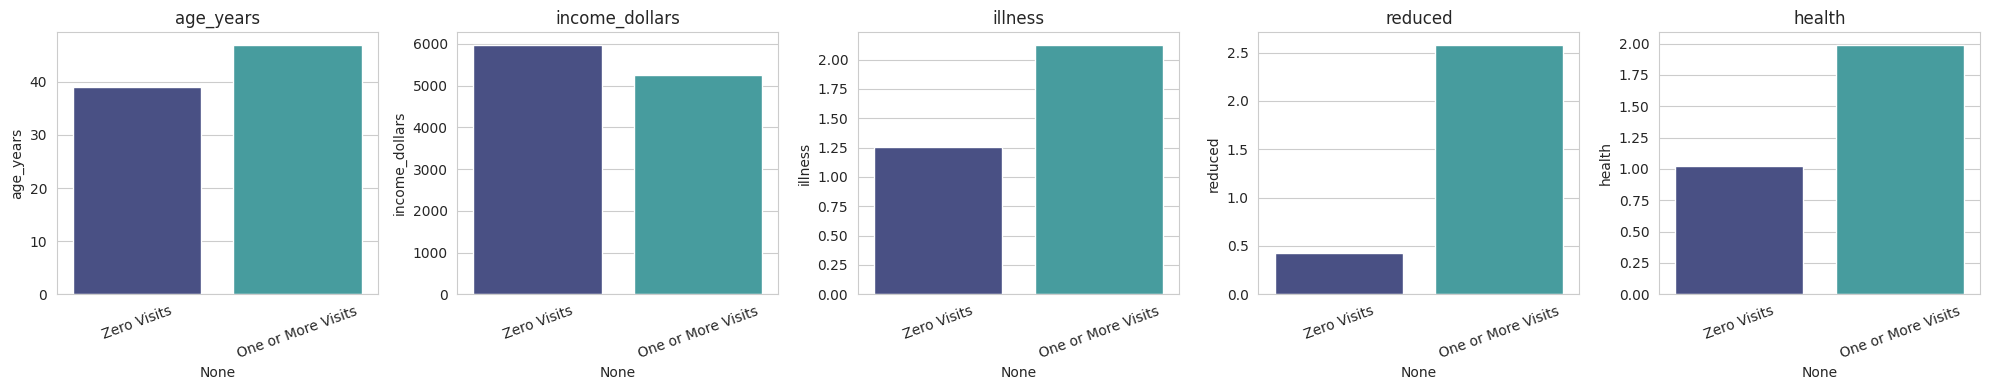


Chi-square test (lchronic vs any_visit): chi2 = 92.35, p-value = 7.27e-22


In [19]:
compare_cols = ['age_years','income_dollars','illness','reduced','health']
comparison = df.groupby('any_visit')[compare_cols].mean()
comparison.index = ['Zero Visits', 'One or More Visits']
print(comparison.round(2))

fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, col in zip(axes, compare_cols):
    sns.barplot(x=comparison.index, y=comparison[col], ax=ax, palette='mako')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

chi2, p, dof, exp = stats.chi2_contingency(pd.crosstab(df['lchronic'], df['any_visit']))
print(f"\nChi-square test (lchronic vs any_visit): chi2 = {chi2:.2f}, p-value = {p:.2e}")

People with **zero visits are on average younger, report better health (lower score), fewer illnesses, and far fewer reduced-activity days** than those with at least one visit. A chi-square test confirms a **highly significant association between having a limiting chronic condition and having visited the doctor at all** (p < 0.0001) — chronic condition status is not just linked to *how many* visits someone makes, but to *whether* they visit at all.

## 12. Multivariate View: Health, Chronic Condition and Visits

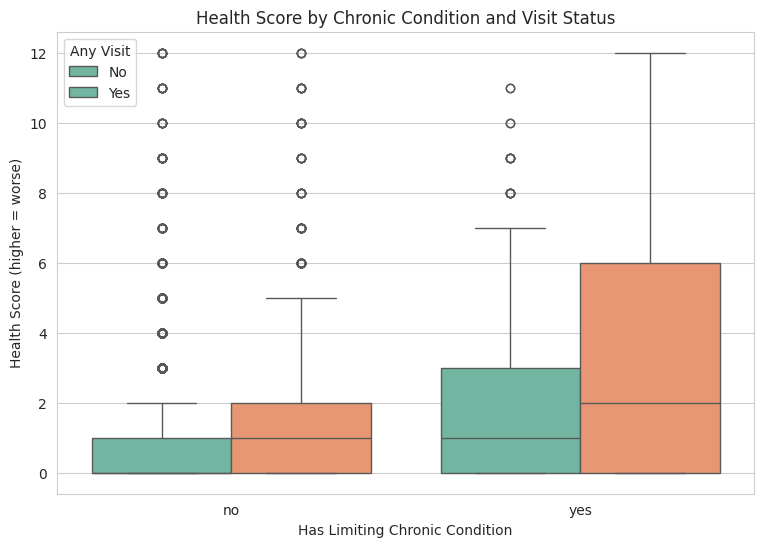

In [20]:
plt.figure(figsize=(9,6))
sns.boxplot(x='lchronic', y='health', hue='any_visit', data=df, palette='Set2')
plt.title('Health Score by Chronic Condition and Visit Status')
plt.xlabel('Has Limiting Chronic Condition')
plt.ylabel('Health Score (higher = worse)')
plt.legend(title='Any Visit', labels=['No', 'Yes'])
plt.show()

Within both chronic-condition groups, people who visited the doctor report **worse self-rated health** than those who didn't — the health score gap persists whether or not someone has a limiting chronic condition, suggesting `health` and doctor visits are linked independently of chronic condition status, not just as a proxy for it.

## 13. Unusual / Unexpected Patterns

- **Private health insurance shows no meaningful effect on visit frequency** (p = 0.57) — counter to the simple assumption that insurance increases access. This is explained by a selection effect: privately insured individuals are wealthier and healthier on average, offsetting any extra access-driven visits.
- **`freepoor` (low-income free insurance) is linked to *fewer* visits, not more** — despite removing the cost barrier, this group visits less than the general population, hinting at non-financial barriers to care.
- **Women visit the doctor significantly more than men** even after accounting for the fact that men and women have similar chronic-condition rates in this data — worth further investigation into whether this reflects health-seeking behaviour differences rather than actual health differences.
- **Income has only a very weak, slightly negative correlation with visits** — despite being a natural candidate for explaining access to care, income is a much weaker driver than health status or chronic condition status in this dataset.

## 14. Key Questions — Summary of Findings

| Question | Finding |
|---|---|
| What predicts doctor visits most strongly? | Limiting chronic condition (`lchronic`) and reduced-activity days — far more than demographics |
| Does gender matter? | Yes — women visit significantly more than men (p < 0.0001) |
| Does age matter? | Yes — visits roughly double from the youngest to oldest age group |
| Does private insurance increase visits? | No measurable effect — explained by a healthy-wealthy selection effect |
| Does government assistance insurance matter? | Yes, but in opposite directions: `freepoor` lowers visits, `freerepat` raises them |
| Does income matter? | Only weakly, and in the opposite direction expected (higher income, marginally fewer visits) |
| What distinguishes people with zero visits? | Younger, healthier, fewer illnesses, far fewer reduced-activity days |
| Is chronic condition linked to *whether* someone visits at all, not just *how much*? | Yes — confirmed via chi-square test (p < 0.0001) |

## Limitations

- **Two-week recall window:** Visit counts reflect only a two-week reference period, not annual healthcare usage, so infrequent but real health needs (e.g. one visit every few months) may be undercounted as "zero visits."
- **Cross-sectional data:** All variables are measured at a single point in time, so we can describe associations (e.g. chronic condition and visits) but cannot establish causation.
- **Self-reported health:** The `health` score and illness/chronic-condition flags are self-reported, which can introduce reporting bias (e.g. under- or over-stating symptoms).
- **No cost or geographic data:** We cannot separate whether lower visits among `freepoor` individuals stem from access barriers, distance to clinics, awareness, or other unmeasured factors.
- **Rescaled variables:** `age` and `income` were rescaled from their encoded units for interpretability; the underlying data may have originally been rounded or bucketed before division, slightly limiting precision.

## Final Conclusion

This analysis set out to understand what drives doctor visits in this population. The clearest answer is that **health need, not access or income, is the dominant driver**: having a limiting chronic condition more than doubles average visits, and this effect holds regardless of insurance type. Demographic factors also matter — **women and older individuals visit significantly more often** — but these effects are far smaller than the impact of an activity-limiting chronic condition.

The insurance findings challenge a simple "more coverage means more care" narrative. **Private insurance shows no measurable effect on visit frequency**, largely because it is held disproportionately by healthier, wealthier individuals who need fewer visits in the first place — a classic selection effect masking any true access benefit. Meanwhile, the two government assistance programs diverge sharply: **`freerepat` (elderly/veteran cover) is associated with substantially more visits**, consistent with the higher health needs of that population, while **`freepoor` (low-income cover) is associated with fewer visits**, suggesting that removing the cost barrier alone does not guarantee that low-income individuals actually access care — other barriers may be at play.

**Recommendation:** Healthcare policy aiming to improve access should look beyond insurance coverage alone and investigate the non-financial barriers facing low-income individuals specifically, since this group visits the doctor least despite having free coverage. Further research with cost, geographic, and multi-year data would help confirm whether these patterns reflect access barriers, health-seeking behaviour, or measurement limitations in this two-week survey window.